Training RBF Network...
Training Complete.


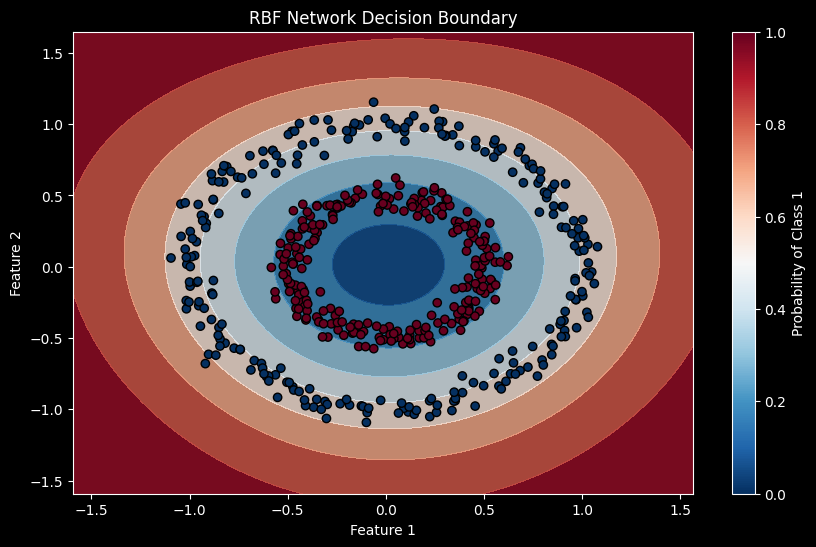

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, initializers
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# 1. Generate Non-Linear Data (The "Bullseye")
# We create two concentric circles. A linear model cannot solve this.
X, y = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)

# 2. Define the Custom RBF Layer
class RBFLayer(layers.Layer):
    def __init__(self, output_dim, gamma=1.0, **kwargs):
        super(RBFLayer, self).__init__(**kwargs)
        self.output_dim = output_dim
        self.gamma = gamma # Controls the "width" of the Gaussian

    def build(self, input_shape):
        # Create a trainable weight variable for the centers of the RBFs
        # Shape: (number of RBF units, input dimension)
        self.centers = self.add_weight(
            name='centers',
            shape=(self.output_dim, input_shape[1]),
            initializer='uniform',
            trainable=True # The network will LEARN where to place the centers
        )
        super(RBFLayer, self).build(input_shape)

    def call(self, inputs):
        # Calculate the squared Euclidean distance between inputs and centers
        # Inputs shape: (batch, input_dim) -> Expand to (batch, 1, input_dim)
        # Centers shape: (output_dim, input_dim)
        # Broadcasting allows us to compute pairwise distances
        diff = tf.expand_dims(inputs, axis=1) - self.centers
        l2 = tf.reduce_sum(tf.square(diff), axis=2)
        
        # Apply the Gaussian function: exp(-gamma * distance^2)
        res = tf.exp(-self.gamma * l2)
        return res

# 3. Build the Model
model = models.Sequential()
# Input: 2D coordinates (x, y)
model.add(layers.Input(shape=(2,))) 
# Hidden: 10 RBF units. They map 2D -> 10D feature space
model.add(RBFLayer(output_dim=10, gamma=0.5)) 
# Output: Standard linear neuron (Sigmoid) to classify 0 or 1
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train
print("Training RBF Network...")
history = model.fit(X, y, epochs=100, batch_size=16, verbose=0)
print("Training Complete.")

# 5. Visualization Function
def plot_decision_boundary(model, X, y):
    # Create a grid of points to map the prediction landscape
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predict on the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = Z.reshape(xx.shape)
    
    # Plot contour and data points
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k')
    plt.title('RBF Network Decision Boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar(label='Probability of Class 1')
    plt.show()

# Run Visualization
plot_decision_boundary(model, X, y)